In [3]:
import sys
sys.path.append('../')

In [4]:
import os
import numpy as np
import pandas as pd
from datetime import timedelta
from tqdm.auto import tqdm
from typing import Any, Dict
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from copy import deepcopy
import pickle
from IPython.display import display

from src.patient_history_helpers import (
    is_mkb,
    is_cancer_mkb,
    get_history_before_event,
    is_target_the_first_cancer,
    n_admissions_before_event,
    n_codes_before_event,
    timedelta_to_event_from_first_record,
    timedelta_to_event_from_prev_record,
    last_timedelta,
)

In [2]:
N_CORES_TO_USE = 64
DATADIR = 'datasets'
SAVE_DIR = "datasets"
FILE_NAME = "trajectories.csv"
# TARGET_CANCER = "C61"
TARGET_CANCER = "C34"
PREDICTION_HORIZON = 3 #years
PREDICTION_HORIZON = 12*PREDICTION_HORIZON #months

In [ ]:
df = pd.read_csv(DATADIR+"/"+FILE_NAME) #used in feature generation also
df['admittime'] = pd.to_datetime(df['admittime'], format='%Y-%m-%d %H:%M:%S')
df['dischtime'] = pd.to_datetime(df['dischtime'], format='%Y-%m-%d %H:%M:%S')
df["dod"] = pd.to_datetime(df['dod'], format='%Y-%m-%d')
df["birth_year"] = pd.to_datetime(df['birth_year'], format='%Y')

In [13]:
df.head()

,subject_id,hadm_id,seq_num,icd10_code,icd10_category,admittime,dischtime,deathtime,gender,birth_year,dod
0,10000032,22595853,1,K766,K76,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
1,10000032,22595853,2,R188,R18,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
2,10000032,22595853,3,K740,K74,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
3,10000032,22595853,4,B1920,B19,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09
4,10000032,22595853,5,J449,J44,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,F,2128-01-01,2180-09-09


In [14]:
df.dtypes

subject_id                 int64
hadm_id                    int64
seq_num                    int64
icd10_code                object
icd10_category            object
admittime         datetime64[ns]
dischtime         datetime64[ns]
deathtime                 object
gender                    object
birth_year        datetime64[ns]
dod               datetime64[ns]
dtype: object

In [15]:
df.shape

(5938215, 11)

# Patients selection (uses prediction horizon)

In [8]:
ALL_VALUES = df['icd10_category'].unique()

In [9]:
MKB_VALUES, CANCER_VALUES = list(), list()
for v in ALL_VALUES:
    if is_mkb(v):
        if is_cancer_mkb(v):
            CANCER_VALUES.append(v)
        else:
            MKB_VALUES.append(v)

### Cancer patients

In [10]:
cancer_patients = df[df['icd10_category'].isin(CANCER_VALUES)][['icd10_category', 'subject_id', 'admittime', "birth_year", "gender"]].groupby(['subject_id']).first().reset_index()
target_cancer_patients = cancer_patients[cancer_patients['icd10_category'] == TARGET_CANCER]
target_cancer_patients.shape

(2915, 5)

/tmp/ipykernel_993090/676371430.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_admissions_before_target_cancer = df[df["subject_id"].isin(target_cancer_patients["subject_id"])].groupby("subject_id").apply(partial(n_admissions_before_event, target=TARGET_CANCER))


<Axes: >

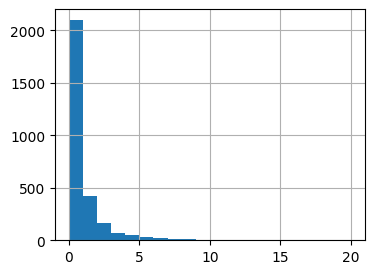

In [11]:
n_admissions_before_target_cancer = df[df["subject_id"].isin(target_cancer_patients["subject_id"])].groupby("subject_id").apply(partial(n_admissions_before_event, target=TARGET_CANCER))
n_admissions_before_target_cancer.hist(bins=range(21), figsize=(4, 3))

In [12]:
target_cancer_patients_with_history = list(n_admissions_before_target_cancer[n_admissions_before_target_cancer >= 1].index)
len(target_cancer_patients_with_history)

819

/tmp/ipykernel_993090/2225045955.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  timedelta_to_target_cancer = df[df["subject_id"].isin(target_cancer_patients_with_history)].groupby("subject_id").apply(partial(timedelta_to_event_from_prev_record, target=TARGET_CANCER))


<Axes: >

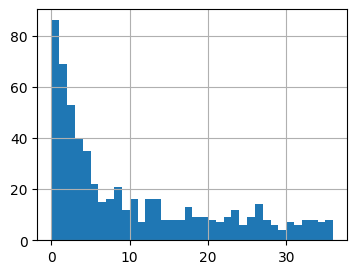

In [13]:
timedelta_to_target_cancer = df[df["subject_id"].isin(target_cancer_patients_with_history)].groupby("subject_id").apply(partial(timedelta_to_event_from_prev_record, target=TARGET_CANCER))
timedelta_to_target_cancer = timedelta_to_target_cancer/30
timedelta_to_target_cancer.hist(bins=range(37), figsize=(4, 3))

In [14]:
timedelta_to_target_cancer.head()

subject_id
10001843    37.366667
10002155    12.333333
10003299     3.700000
10026255     9.733333
10042810    44.966667
dtype: float64

In [15]:
timedelta_to_target_cancer = pd.DataFrame({
    "subject_id": list(timedelta_to_target_cancer.index),
    "timedelta_to_index": list(timedelta_to_target_cancer.values), 
})

In [16]:
timedelta_to_target_cancer.head()

,subject_id,timedelta_to_index
0,10001843,37.366667
1,10002155,12.333333
2,10003299,3.700000
3,10026255,9.733333
4,10042810,44.966667


In [17]:
target_cancer_patients = pd.merge(
    how="right",
    left=cancer_patients,
    right=timedelta_to_target_cancer,
    on="subject_id",
)

In [18]:
target_cancer_patients.head()

,subject_id,icd10_category,admittime,birth_year,gender,timedelta_to_index
0,10001843,C34,2134-12-05 00:10:00,2058-01-01,M,37.366667
1,10002155,C34,2129-08-04 12:44:00,2048-01-01,F,12.333333
2,10003299,C34,2183-06-18 22:34:00,2108-01-01,F,3.700000
3,10026255,C34,2201-07-07 18:15:00,2134-01-01,M,9.733333
4,10042810,C34,2177-01-13 17:40:00,2112-01-01,F,44.966667


In [19]:
target_cancer_patients.count()

subject_id            819
icd10_category        819
admittime             819
birth_year            819
gender                819
timedelta_to_index    819
dtype: int64

In [ ]:
target_cancer_patients.to_csv(f"{SAVE_DIR}/{TARGET_CANCER}_patients.csv", index=False)

### Healthy controls

In [21]:
healthy_patients = df[~df['subject_id'].isin(cancer_patients.index)][['subject_id', 'admittime', "birth_year", "gender"]].groupby(['subject_id']).last().reset_index()

In [22]:
healthy_patients.head()

,subject_id,admittime,birth_year,gender
0,10000032,2180-08-05 23:44:00,2128-01-01,F
1,10000068,2160-03-03 23:16:00,2141-01-01,F
2,10000084,2160-12-28 05:11:00,2088-01-01,M
3,10000108,2163-09-27 23:17:00,2138-01-01,M
4,10000117,2183-09-18 18:10:00,2126-01-01,F


In [23]:
healthy_patients.shape

(223291, 4)

/tmp/ipykernel_993090/244387413.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_admissions = df[df["subject_id"].isin(healthy_patients["subject_id"])].groupby("subject_id").apply(lambda x: x["hadm_id"].nunique())


<Axes: >

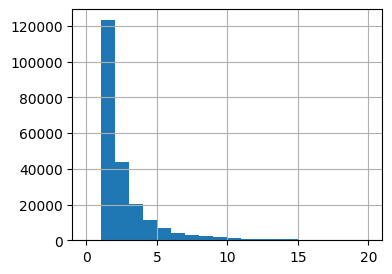

In [24]:
n_admissions = df[df["subject_id"].isin(healthy_patients["subject_id"])].groupby("subject_id").apply(lambda x: x["hadm_id"].nunique())
n_admissions.hist(bins=range(21), figsize=(4, 3))

In [25]:
healthy_patients_with_history = list(n_admissions[n_admissions > 1].index)
len(healthy_patients_with_history)

100057

/tmp/ipykernel_993090/1699065766.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hp_last_timedelta = df[df["subject_id"].isin(healthy_patients_with_history)].groupby("subject_id").apply(last_timedelta)


<Axes: >

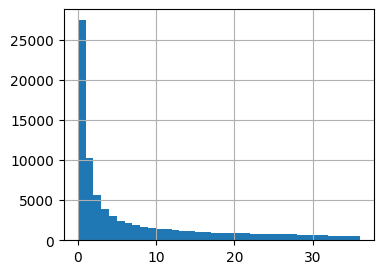

In [26]:
hp_last_timedelta = df[df["subject_id"].isin(healthy_patients_with_history)].groupby("subject_id").apply(last_timedelta)
hp_last_timedelta = hp_last_timedelta/30
hp_last_timedelta.hist(bins=range(37), figsize=(4, 3))

In [27]:
hp_last_timedelta.head()

subject_id
10000032     0.433333
10000084     1.233333
10000117    22.400000
10000635    91.433333
10000690    15.066667
dtype: float64

In [28]:
hp_last_timedelta = pd.DataFrame({
    "subject_id": list(hp_last_timedelta.index),
    "timedelta_to_index": list(hp_last_timedelta.values), 
})

In [29]:
hp_last_timedelta.head()

,subject_id,timedelta_to_index
0,10000032,0.433333
1,10000084,1.233333
2,10000117,22.400000
3,10000635,91.433333
4,10000690,15.066667


In [30]:
healthy_patients_with_history = pd.merge(
    how="right",
    left=healthy_patients,
    right=hp_last_timedelta,
    on="subject_id",
)

In [31]:
healthy_patients_with_history.head()

,subject_id,admittime,birth_year,gender,timedelta_to_index
0,10000032,2180-08-05 23:44:00,2128-01-01,F,0.433333
1,10000084,2160-12-28 05:11:00,2088-01-01,M,1.233333
2,10000117,2183-09-18 18:10:00,2126-01-01,F,22.400000
3,10000635,2143-12-23 14:55:00,2062-01-01,F,91.433333
4,10000690,2152-01-28 23:40:00,2064-01-01,F,15.066667


In [32]:
healthy_patients_with_history.count()

subject_id            100057
admittime             100057
birth_year            100057
gender                100057
timedelta_to_index    100057
dtype: int64

In [ ]:
healthy_patients_with_history.to_csv(f"{SAVE_DIR}/healthy_patients_with_history.csv", index=False)

### Some auxiliary columns

In [34]:
target_cancer_patients["age"] = target_cancer_patients.apply(lambda x: (x["admittime"] - x["birth_year"]).days/365.25, axis=1)
healthy_patients_with_history["age"] = healthy_patients_with_history.apply(lambda x: (x["admittime"] - x["birth_year"]).days/365.25, axis=1)

In [35]:
target_cancer_patients = pd.merge(
    how="left",
    left=target_cancer_patients,
    right=n_admissions_before_target_cancer.reset_index().rename({0: "n_admissions"}, axis=1),
    on="subject_id"
)
print(target_cancer_patients.count())

healthy_patients_with_history = pd.merge(
    how="left",
    left=healthy_patients_with_history,
    right=n_admissions.reset_index().rename({0: "n_admissions"}, axis=1),
    on="subject_id"
)
print(healthy_patients_with_history.count())

subject_id            819
icd10_category        819
admittime             819
birth_year            819
gender                819
timedelta_to_index    819
age                   819
n_admissions          819
dtype: int64
subject_id            100057
admittime             100057
birth_year            100057
gender                100057
timedelta_to_index    100057
age                   100057
n_admissions          100057
dtype: int64


In [36]:
target_cancer_patients.to_csv(f"{SAVE_DIR}/{TARGET_CANCER}_patients.csv", index=False)
healthy_patients_with_history.to_csv(f"{SAVE_DIR}/healthy_patients_with_history.csv", index=False)

In [37]:
AGE_STEP = 5 # years
target_cancer_patients["age_bin"] = target_cancer_patients["age"].apply(lambda x: int(x / AGE_STEP))
healthy_patients_with_history["age_bin"] = healthy_patients_with_history["age"].apply(lambda x: int(x / AGE_STEP))

In [38]:
TIMEDELTA_STEP = 1 # months
target_cancer_patients["timedelta_bin"] = target_cancer_patients["timedelta_to_index"].apply(lambda x: int(x / TIMEDELTA_STEP))
healthy_patients_with_history["timedelta_bin"] = healthy_patients_with_history["timedelta_to_index"].apply(lambda x: int(x / TIMEDELTA_STEP))

### Matching

In [39]:
target_cancer_patients.shape

(819, 10)

In [40]:
target_cancer_patients_horizoned = target_cancer_patients[target_cancer_patients["timedelta_to_index"] < PREDICTION_HORIZON]
target_cancer_patients_horizoned.shape

(606, 10)

In [41]:
RANDOM_STATE = 42
matched_cancer_patients = pd.DataFrame()
matched_healthy_patients = pd.DataFrame()

for gender in tqdm(sorted(target_cancer_patients_horizoned["gender"].unique())):
    for age_bin in tqdm(sorted(target_cancer_patients_horizoned["age_bin"].unique())):
        for timedelta_bin in sorted(target_cancer_patients_horizoned["timedelta_bin"].unique()):
            bin_cancer_patients = target_cancer_patients_horizoned[
                (target_cancer_patients_horizoned["gender"] == gender) & \
                (target_cancer_patients_horizoned["age_bin"] == age_bin) & \
                (target_cancer_patients_horizoned["timedelta_bin"] == timedelta_bin)
            ]
            n_cancer_patients = len(bin_cancer_patients)
            if n_cancer_patients == 0:
                continue
            bin_healthy_patients = healthy_patients_with_history[
                (healthy_patients_with_history["gender"] == gender) & \
                (healthy_patients_with_history["age_bin"] == age_bin) & \
                (healthy_patients_with_history["timedelta_bin"] == timedelta_bin)
            ]
            n_healthy_patients = len(bin_healthy_patients)
            print("gender:", gender, "age:", age_bin*AGE_STEP, "timedelta:", timedelta_bin*TIMEDELTA_STEP, "n_cancer", n_cancer_patients, "n_healthy", n_healthy_patients)
            if n_healthy_patients < n_cancer_patients:
                bin_cancer_patients = bin_cancer_patients.sample(n=n_healthy_patients, random_state=RANDOM_STATE) #TODO: to match by history length
            elif n_healthy_patients > n_cancer_patients:
                bin_healthy_patients = bin_healthy_patients.sample(n=n_cancer_patients, random_state=RANDOM_STATE)

            matched_cancer_patients = pd.concat([matched_cancer_patients, bin_cancer_patients])
            matched_healthy_patients = pd.concat([matched_healthy_patients, bin_healthy_patients])

  0%|          | 0/2 [00:00<?, ?it/s]

gender: F age: 40 timedelta: 8 n_cancer 1 n_healthy 33
gender: F age: 50 timedelta: 0 n_cancer 2 n_healthy 894
gender: F age: 50 timedelta: 1 n_cancer 1 n_healthy 316
gender: F age: 50 timedelta: 2 n_cancer 3 n_healthy 167
gender: F age: 50 timedelta: 3 n_cancer 1 n_healthy 124
gender: F age: 50 timedelta: 8 n_cancer 1 n_healthy 61
gender: F age: 50 timedelta: 10 n_cancer 1 n_healthy 52
gender: F age: 50 timedelta: 14 n_cancer 1 n_healthy 34
gender: F age: 50 timedelta: 27 n_cancer 1 n_healthy 26
gender: F age: 55 timedelta: 0 n_cancer 4 n_healthy 1027
gender: F age: 55 timedelta: 1 n_cancer 1 n_healthy 432
gender: F age: 55 timedelta: 3 n_cancer 1 n_healthy 159
gender: F age: 55 timedelta: 5 n_cancer 1 n_healthy 86
gender: F age: 55 timedelta: 7 n_cancer 1 n_healthy 71
gender: F age: 55 timedelta: 10 n_cancer 1 n_healthy 59
gender: F age: 55 timedelta: 14 n_cancer 1 n_healthy 52
gender: F age: 55 timedelta: 15 n_cancer 1 n_healthy 39
gender: F age: 55 timedelta: 18 n_cancer 1 n_health

gender: F age: 65 timedelta: 4 n_cancer 4 n_healthy 147
gender: F age: 65 timedelta: 5 n_cancer 2 n_healthy 128
gender: F age: 65 timedelta: 6 n_cancer 4 n_healthy 117
gender: F age: 65 timedelta: 10 n_cancer 2 n_healthy 60
gender: F age: 65 timedelta: 11 n_cancer 1 n_healthy 73
gender: F age: 65 timedelta: 13 n_cancer 2 n_healthy 46
gender: F age: 65 timedelta: 17 n_cancer 1 n_healthy 33
gender: F age: 65 timedelta: 20 n_cancer 1 n_healthy 54
gender: F age: 65 timedelta: 22 n_cancer 2 n_healthy 29
gender: F age: 65 timedelta: 23 n_cancer 2 n_healthy 33
gender: F age: 65 timedelta: 24 n_cancer 1 n_healthy 27
gender: F age: 65 timedelta: 29 n_cancer 1 n_healthy 27
gender: F age: 65 timedelta: 30 n_cancer 1 n_healthy 24
gender: F age: 65 timedelta: 31 n_cancer 3 n_healthy 37
gender: F age: 70 timedelta: 0 n_cancer 8 n_healthy 1071
gender: F age: 70 timedelta: 1 n_cancer 9 n_healthy 528
gender: F age: 70 timedelta: 2 n_cancer 2 n_healthy 281
gender: F age: 70 timedelta: 3 n_cancer 5 n_hea

gender: F age: 75 timedelta: 17 n_cancer 2 n_healthy 41
gender: F age: 75 timedelta: 19 n_cancer 1 n_healthy 27
gender: F age: 75 timedelta: 21 n_cancer 1 n_healthy 44
gender: F age: 75 timedelta: 22 n_cancer 1 n_healthy 34
gender: F age: 75 timedelta: 23 n_cancer 1 n_healthy 25
gender: F age: 75 timedelta: 25 n_cancer 1 n_healthy 30
gender: F age: 75 timedelta: 26 n_cancer 1 n_healthy 41
gender: F age: 75 timedelta: 30 n_cancer 1 n_healthy 22
gender: F age: 75 timedelta: 31 n_cancer 2 n_healthy 23
gender: F age: 75 timedelta: 32 n_cancer 1 n_healthy 32
gender: F age: 75 timedelta: 33 n_cancer 1 n_healthy 18
gender: F age: 75 timedelta: 34 n_cancer 1 n_healthy 21
gender: F age: 80 timedelta: 0 n_cancer 6 n_healthy 925
gender: F age: 80 timedelta: 1 n_cancer 3 n_healthy 457
gender: F age: 80 timedelta: 2 n_cancer 7 n_healthy 233
gender: F age: 80 timedelta: 3 n_cancer 2 n_healthy 157
gender: F age: 80 timedelta: 4 n_cancer 5 n_healthy 124
gender: F age: 80 timedelta: 5 n_cancer 2 n_heal

gender: F age: 80 timedelta: 18 n_cancer 2 n_healthy 45
gender: F age: 80 timedelta: 21 n_cancer 1 n_healthy 34
gender: F age: 80 timedelta: 22 n_cancer 1 n_healthy 36
gender: F age: 80 timedelta: 24 n_cancer 1 n_healthy 31
gender: F age: 80 timedelta: 25 n_cancer 1 n_healthy 29
gender: F age: 80 timedelta: 26 n_cancer 2 n_healthy 28
gender: F age: 80 timedelta: 28 n_cancer 1 n_healthy 37
gender: F age: 80 timedelta: 30 n_cancer 2 n_healthy 26
gender: F age: 80 timedelta: 32 n_cancer 1 n_healthy 21
gender: F age: 80 timedelta: 35 n_cancer 1 n_healthy 19
gender: F age: 85 timedelta: 0 n_cancer 1 n_healthy 780
gender: F age: 85 timedelta: 1 n_cancer 3 n_healthy 372
gender: F age: 85 timedelta: 2 n_cancer 3 n_healthy 225
gender: F age: 85 timedelta: 3 n_cancer 2 n_healthy 126
gender: F age: 85 timedelta: 5 n_cancer 1 n_healthy 89
gender: F age: 85 timedelta: 6 n_cancer 1 n_healthy 88
gender: F age: 85 timedelta: 8 n_cancer 1 n_healthy 76
gender: F age: 85 timedelta: 12 n_cancer 1 n_health

...

gender: M age: 65 timedelta: 29 n_cancer 1 n_healthy 29
gender: M age: 65 timedelta: 35 n_cancer 2 n_healthy 23
gender: M age: 70 timedelta: 0 n_cancer 8 n_healthy 1310
gender: M age: 70 timedelta: 1 n_cancer 6 n_healthy 579
gender: M age: 70 timedelta: 2 n_cancer 3 n_healthy 323
gender: M age: 70 timedelta: 3 n_cancer 6 n_healthy 200
gender: M age: 70 timedelta: 5 n_cancer 2 n_healthy 118
gender: M age: 70 timedelta: 8 n_cancer 1 n_healthy 101
gender: M age: 70 timedelta: 9 n_cancer 1 n_healthy 80
gender: M age: 70 timedelta: 12 n_cancer 2 n_healthy 57
gender: M age: 70 timedelta: 13 n_cancer 3 n_healthy 68
gender: M age: 70 timedelta: 14 n_cancer 1 n_healthy 55
gender: M age: 70 timedelta: 15 n_cancer 1 n_healthy 57
gender: M age: 70 timedelta: 18 n_cancer 1 n_healthy 51
gender: M age: 70 timedelta: 19 n_cancer 1 n_healthy 41
gender: M age: 70 timedelta: 21 n_cancer 1 n_healthy 41
gender: M age: 70 timedelta: 23 n_cancer 1 n_healthy 32
gender: M age: 70 timedelta: 27 n_cancer 1 n_hea

gender: M age: 75 timedelta: 22 n_cancer 1 n_healthy 30
gender: M age: 75 timedelta: 23 n_cancer 2 n_healthy 31
gender: M age: 75 timedelta: 25 n_cancer 1 n_healthy 33
gender: M age: 75 timedelta: 26 n_cancer 2 n_healthy 26
gender: M age: 75 timedelta: 28 n_cancer 1 n_healthy 27
gender: M age: 75 timedelta: 32 n_cancer 1 n_healthy 19
gender: M age: 75 timedelta: 33 n_cancer 2 n_healthy 21
gender: M age: 75 timedelta: 34 n_cancer 2 n_healthy 19
gender: M age: 80 timedelta: 0 n_cancer 6 n_healthy 980
gender: M age: 80 timedelta: 1 n_cancer 3 n_healthy 474
gender: M age: 80 timedelta: 2 n_cancer 3 n_healthy 240
gender: M age: 80 timedelta: 3 n_cancer 5 n_healthy 130
gender: M age: 80 timedelta: 4 n_cancer 3 n_healthy 118
gender: M age: 80 timedelta: 5 n_cancer 2 n_healthy 98
gender: M age: 80 timedelta: 6 n_cancer 1 n_healthy 82
gender: M age: 80 timedelta: 7 n_cancer 3 n_healthy 82
gender: M age: 80 timedelta: 8 n_cancer 1 n_healthy 66
gender: M age: 80 timedelta: 12 n_cancer 1 n_healthy

gender: M age: 85 timedelta: 9 n_cancer 1 n_healthy 46
gender: M age: 85 timedelta: 10 n_cancer 1 n_healthy 43
gender: M age: 85 timedelta: 15 n_cancer 1 n_healthy 30
gender: M age: 85 timedelta: 21 n_cancer 1 n_healthy 16
gender: M age: 85 timedelta: 22 n_cancer 1 n_healthy 22
gender: M age: 85 timedelta: 23 n_cancer 1 n_healthy 27
gender: M age: 85 timedelta: 30 n_cancer 1 n_healthy 23
gender: M age: 85 timedelta: 31 n_cancer 1 n_healthy 21
gender: M age: 85 timedelta: 35 n_cancer 2 n_healthy 17
gender: M age: 90 timedelta: 0 n_cancer 5 n_healthy 464
gender: M age: 90 timedelta: 1 n_cancer 5 n_healthy 221
gender: M age: 90 timedelta: 2 n_cancer 2 n_healthy 104
gender: M age: 90 timedelta: 4 n_cancer 3 n_healthy 65
gender: M age: 90 timedelta: 12 n_cancer 1 n_healthy 21
gender: M age: 90 timedelta: 13 n_cancer 2 n_healthy 19
gender: M age: 90 timedelta: 25 n_cancer 1 n_healthy 17
gender: M age: 90 timedelta: 26 n_cancer 1 n_healthy 12


100%|██████████| 2/2 [00:03<00:00,  1.59s/it]

gender: M age: 90 timedelta: 27 n_cancer 1 n_healthy 8
gender: M age: 95 timedelta: 10 n_cancer 1 n_healthy 8


In [42]:
matched_cancer_patients.shape, matched_healthy_patients.shape

((606, 10), (606, 9))

In [43]:
matched_patients = pd.concat([
    matched_cancer_patients,
    matched_healthy_patients
], axis=0)
matched_patients.shape

(1212, 10)

In [44]:
matched_patients.sample(5)

,subject_id,icd10_category,admittime,birth_year,gender,timedelta_to_index,age,n_admissions,age_bin,timedelta_bin
616,17517641,C34,2127-04-11 16:02:00,2046-01-01,F,1.066667,81.270363,4,16,1
192,12487770,C34,2165-12-22 15:19:00,2103-01-01,F,15.400000,62.973306,1,12,15
790,19680373,C34,2127-12-25 12:00:00,2066-01-01,M,9.366667,61.976728,1,12,9
279,13452138,C34,2132-07-30 19:00:00,2068-01-01,M,10.866667,64.574949,2,12,10
526,16444272,C34,2141-07-05 21:53:00,2076-01-01,F,2.266667,65.505818,1,13,2


In [45]:
matched_patients.to_csv(f"{SAVE_DIR}/{TARGET_CANCER}_matched_patients.csv", index=False)

In [46]:
#healthy
matched_patients[matched_patients["icd10_category"].isna()].n_admissions.mean(), matched_patients[matched_patients["icd10_category"].isna()].n_admissions.std()

(4.542904290429043, 4.2481662526121555)

In [47]:
#cancer
matched_patients[matched_patients["icd10_category"].notna()].n_admissions.mean(), matched_patients[matched_patients["icd10_category"].notna()].n_admissions.std()

(2.7953795379537953, 3.426350747149174)

# Features generation

In [5]:
matched_patients = pd.read_csv(f"{SAVE_DIR}/{TARGET_CANCER}_matched_patients.csv").set_index("subject_id", drop=True)
matched_cancer_patients = matched_patients[matched_patients["icd10_category"].notna()]
matched_healthy_patients = matched_patients[matched_patients["icd10_category"].isna()]
matched_cancer_patients.shape, matched_healthy_patients.shape

((606, 9), (606, 9))

In [20]:
def get_features_from_history(patient_df, embeddings, agg=np.nanmean):
    embeddings_sequence = np.stack([x for x in patient_df["icd10_category"].apply(lambda x: embeddings[x] if x in embeddings else None).values if x is not None])
    return agg(
        embeddings_sequence, 
        axis=0
    )

#for parallel computing
def build_patient_sample(args):
    is_cancer, p, r, embeddings, model = args
    date_index = r['admittime'] #time of last admission or time of cancer diagnosis
    patient_df = df[df["subject_id"] == p]

    if is_cancer:
        patient_df_prev = get_history_before_event(patient_df, target=TARGET_CANCER)
    else:
        patient_df_prev = patient_df[patient_df["admittime"] != date_index]
        
    if model == "baseline": #for baseline
        row = patient_df_prev["icd10_category"].value_counts().to_dict()
    elif model.startswith("random"): #for random
        rng = np.random.default_rng(embeddings["seed"]+p)
        row = {f"feature_{i}": v for i, v in enumerate(rng.standard_normal(size=embeddings["dim"]))}
    else: #for llms
        row = get_features_from_history(patient_df_prev, embeddings)
        row = {f"feature_{i}": v for i, v in enumerate(row)}
    
    row["Y"] = int(is_cancer)
    row["subject_id"] = p

    return row

In [21]:
# MODEL = "deepseek-ai_DeepSeek-V3"
# MODEL = "openai_gpt-oss-120b"
# MODEL = "baseline"
MODEL = "random_4096"

# for aggregation in ["_max", "_mean"]:
#     print(aggregation)
#     for reasoning_effort in ["Low", "Medium", "High"]:
#         print(reasoning_effort)
if MODEL.startswith("openai_gpt-oss-120b"):
    MODEL_REASONING = "{MODEL}_{reasoning_effort}".format(MODEL=MODEL, reasoning_effort=reasoning_effort)
else:
    MODEL_REASONING = MODEL

if MODEL == "baseline":
    embeddings = None
    aggregation = ""
elif MODEL.startswith("random"):
    embeddings = {
        "dim": int(MODEL.split("_")[-1]),
        "seed": 42
    }
    aggregation = ""
else:
    with open(f"embeddings/{MODEL_REASONING}{aggregation}.pkl", "rb") as f:
        embeddings = pickle.load(f)
    print(embeddings.keys())
    embeddings = {k: v.float().numpy() for k, v in embeddings.items()}
    print(embeddings['A01'])

#for parallel computing
cancer_args = [(True, p, r, embeddings, MODEL) for p, r in matched_cancer_patients.iterrows()]
health_args = [(False, p, r, embeddings, MODEL) for p, r in matched_healthy_patients.iterrows()]
all_args = health_args + cancer_args

X = []
for args in tqdm(all_args):
    patient_row = build_patient_sample(args)
    X.append(patient_row)
X = pd.DataFrame(X)
X = X.fillna(0) #for baseline
print(X.shape)
display(X.head())

X.to_csv(f"{SAVE_DIR}/{TARGET_CANCER}_{MODEL_REASONING.replace('/', '_')}_features{aggregation}.csv", index=False)

100%|██████████| 1212/1212 [00:07<00:00, 156.70it/s]


(1212, 4098)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_4088,feature_4089,feature_4090,feature_4091,feature_4092,feature_4093,feature_4094,feature_4095,Y,subject_id
0,0.696503,0.246656,-0.141048,0.837603,-1.900778,0.391382,0.479006,0.529559,0.320904,-0.009354,...,-1.187307,-0.954995,-1.586758,-0.100956,1.730324,-1.900175,-0.739349,-2.473983,0,19215324
1,0.445765,0.296131,1.489578,-1.032341,0.748323,1.300826,1.833488,0.626246,-0.247960,-1.316614,...,-1.362276,1.301933,0.607987,1.147371,0.299266,0.729149,0.909554,1.775842,0,18004443
2,0.403246,-0.408852,-0.890751,-0.105589,0.054010,-0.491507,0.583081,-1.484029,-0.463514,0.296430,...,0.354472,-0.808414,0.195630,-0.548395,0.849645,1.914890,1.641173,0.126473,0,14817209
3,-0.516901,-0.173452,0.462918,-0.942034,-1.217982,0.061499,0.646415,-0.359801,-0.528039,0.419595,...,0.031645,-0.802434,-0.113217,-0.296564,1.449010,0.406231,-0.284227,0.213177,0,15662946
4,-2.321539,0.440301,0.551916,0.684245,-0.215011,-0.275238,0.008376,0.041937,0.549886,-0.737435,...,0.011428,-0.239558,-1.303998,-0.020643,-0.286109,-0.497098,0.038224,-0.267412,0,16044160
